In [159]:
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import plotly.express as px

<h3>Preprocessing Images

In [5]:
# gliomas
glioma = None
for i in range(1, 2005):
    i_mod = i
    if i < 10:
        i_mod = f"000{i}"
    elif i < 100:
        i_mod = f"00{i}"
    elif i < 1000:
        i_mod = f"0{i}"
    img = Image.open(f"brain_glioma_{i_mod}.jpg").convert("L")

    if glioma is None:
        glioma = np.array(img).flatten()

    else:
        glioma = np.vstack([glioma, np.array(img).flatten()])

glioma
    

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [6]:
# menins
menin = None
for i in range(1, 2005):
    i_mod = i
    if i < 10:
        i_mod = f"000{i}"
    elif i < 100:
        i_mod = f"00{i}"
    elif i < 1000:
        i_mod = f"0{i}"
    img = Image.open(f"brain_menin_{i_mod}.jpg").convert("L")

    if menin is None:
        menin = np.array(img).flatten()

    else:
        menin = np.vstack([menin, np.array(img).flatten()])

menin

array([[0, 0, 0, ..., 2, 2, 3],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [7]:
tumor = None
for i in range(1, 2005):
    i_mod = i
    if i < 10:
        i_mod = f"000{i}"
    elif i < 100:
        i_mod = f"00{i}"
    elif i < 1000:
        i_mod = f"0{i}"
    img = Image.open(f"brain_tumor_{i_mod}.jpg").convert("L")

    if tumor is None:
        tumor = np.array(img).flatten()

    else:
        tumor = np.vstack([tumor, np.array(img).flatten()])

tumor

array([[0, 0, 0, ..., 6, 6, 6],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 5, 4, 2],
       ...,
       [0, 0, 0, ..., 5, 5, 4],
       [2, 2, 2, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [8]:
# consolidate into one dataframe
all_data = pd.DataFrame(np.vstack([glioma, menin, tumor]))

# add class labels
all_data = all_data.reset_index()

# 0 is for gliomas, 1 is for menins, 2 is for tumors
all_data["type"] = np.where(all_data["index"] < 2004, 0, np.where(all_data["index"] < 4008, 1, 2))
all_data.drop("index", axis = 1, inplace = True)
all_data

,0,1,2,3,4,5,6,7,8,9,...,262135,262136,262137,262138,262139,262140,262141,262142,262143,type
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6007,1,0,0,0,0,1,2,3,3,3,...,5,5,5,5,4,4,3,3,3,2
6008,0,0,2,3,4,3,2,1,0,1,...,0,0,0,0,0,0,0,0,0,2
6009,0,0,0,0,0,0,0,0,0,0,...,6,4,5,5,6,6,5,5,4,2
6010,2,2,2,2,2,2,2,2,1,1,...,1,0,0,0,0,0,0,0,0,2


<h3> PCA

In [21]:
X = all_data.iloc[:, 0:262144]
X

,0,1,2,3,4,5,6,7,8,9,...,262134,262135,262136,262137,262138,262139,262140,262141,262142,262143
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6007,1,0,0,0,0,1,2,3,3,3,...,4,5,5,5,5,4,4,3,3,3
6008,0,0,2,3,4,3,2,1,0,1,...,0,0,0,0,0,0,0,0,0,0
6009,0,0,0,0,0,0,0,0,0,0,...,6,6,4,5,5,6,6,5,5,4
6010,2,2,2,2,2,2,2,2,1,1,...,1,1,0,0,0,0,0,0,0,0


In [24]:
pca = PCA(n_components = 5)

pca.fit(X)

PCA(n_components=5)

In [28]:
pca.explained_variance_ratio_.sum()

0.2964933993760231

In [29]:
pca2 = PCA(n_components=100)
pca2.fit(X)

PCA(n_components=100)

In [30]:
pca2.explained_variance_ratio_.sum()

0.6271766919886156

In [31]:
pca3 = PCA(n_components=500)
pca3.fit(X)

PCA(n_components=500)

In [32]:
pca3.explained_variance_ratio_.sum()

0.8355508922034816

In [33]:
pca4 = PCA(n_components=1000)
pca4.fit(X)

PCA(n_components=1000)

In [38]:
pca4.explained_variance_ratio_.cumsum()

array([0.1078375 , 0.17666954, 0.24233461, 0.27382516, 0.2964934 ,
       0.3126659 , 0.32734604, 0.33968288, 0.35064547, 0.36046747,
       0.36982196, 0.37891982, 0.38678935, 0.39419011, 0.40105371,
       0.40755054, 0.41384197, 0.41988806, 0.42544796, 0.43079718,
       0.43593391, 0.44085933, 0.44566695, 0.45036727, 0.45489213,
       0.45934082, 0.46362869, 0.46786185, 0.47200175, 0.47599849,
       0.47980907, 0.48348905, 0.48708149, 0.4905538 , 0.49400207,
       0.49729906, 0.50055913, 0.50374944, 0.50686621, 0.5098753 ,
       0.51286608, 0.51574131, 0.51855805, 0.52135776, 0.52411915,
       0.52685013, 0.52954315, 0.53217032, 0.53470862, 0.53722398,
       0.53972098, 0.54213741, 0.54451441, 0.54685499, 0.54916353,
       0.55143717, 0.5537018 , 0.555875  , 0.55803371, 0.56014212,
       0.56223722, 0.56430265, 0.56633319, 0.56835723, 0.57036495,
       0.5723177 , 0.57425932, 0.57618124, 0.57806457, 0.57993722,
       0.58179417, 0.58363311, 0.58542427, 0.58720317, 0.58897

In [40]:
pca4.components_.shape

(1000, 262144)

In [41]:
X_pca = pca4.transform(X)

In [43]:
X_pca.shape

(6012, 1000)

In [52]:
pca_df = pd.concat([pd.DataFrame(X_pca), all_data["type"]], axis = 1)
pca_df

,0,1,2,3,4,5,6,7,8,9,...,991,992,993,994,995,996,997,998,999,type
0,-12146.710466,-1468.210120,1992.840871,-8685.993791,137.585374,1563.024192,-1360.573413,1690.135517,-124.329408,-1056.399066,...,83.245215,-31.737740,135.412937,55.325439,5.452892,-202.349136,61.867077,-318.366722,-21.271102,0
1,-2076.941491,6053.126258,5901.665908,-232.253162,1534.061889,-1862.140378,1151.368046,927.577451,637.115306,2809.069201,...,-27.162562,94.910771,-72.876410,112.526191,-228.762290,370.404086,-123.725870,-204.964905,123.864239,0
2,-8752.831400,-3219.861711,4140.007062,-4519.518417,2906.420033,978.433784,-2570.261616,753.899134,1462.364267,-1971.122186,...,204.421979,-22.911701,-221.134812,51.355086,-31.996507,111.373305,12.606114,-138.084569,-96.636048,0
3,-4844.097751,-5061.612813,7279.554244,-4679.639328,-366.337808,-1614.243944,301.978121,-578.866201,2360.802520,-100.120623,...,-192.648656,205.227003,-263.366550,21.337992,-90.368535,115.527083,-183.624097,109.361418,-133.588462,0
4,-6582.409949,1447.055481,-1132.655882,668.706118,371.529739,-1867.331314,-1261.701382,2146.488750,-5425.130606,-3931.287913,...,-15.078396,-284.086775,-27.618752,30.861060,187.877251,61.114411,-34.529393,-10.621134,-34.976892,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6007,5884.388094,4732.814738,9841.962354,15.176166,-3860.315430,206.495246,1774.364616,-5584.748137,3303.585186,-540.128348,...,-85.732938,-61.607160,120.190903,-83.831478,162.432696,72.117409,-157.504967,-78.187434,155.182108,2
6008,5370.661697,1641.820622,-5182.799647,-1745.382878,1888.713454,2297.507645,-774.871775,-535.681620,97.863103,397.130098,...,-127.410938,249.990994,38.065564,260.901511,-116.502171,-8.961471,205.196149,-82.012755,-10.946949,2
6009,6907.266799,-6475.421392,-4562.245024,-2231.034247,4781.562581,-3261.499092,-1426.494770,-3231.248052,-975.347675,-2840.399731,...,-212.244235,-175.414093,500.736538,31.409425,-4.186085,-95.087896,80.157395,52.011204,-122.784161,2
6010,7473.485322,4246.690268,-3868.500818,-1504.839703,1881.786554,3887.142374,-1027.737293,534.257408,-605.986368,3318.206866,...,197.936968,18.552073,-150.128267,84.890751,-296.047056,-129.811679,-17.317226,-79.264916,356.303746,2


In [57]:
X_train, X_test, y_train, y_test = train_test_split(pca_df.iloc[:, 0:1000], pca_df["type"], random_state = 42)

<h3> Baseline Classification - Logistic Regression

In [60]:
logreg_model = LogisticRegression(max_iter = 1000, warm_start = True)
logreg_model.fit(X_train, y_train)

/Users/sami/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, warm_start=True)

In [61]:
logreg_model = LogisticRegression(max_iter = 10000, warm_start = True)
logreg_model.fit(X_train, y_train)

/Users/sami/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=10000, warm_start=True)

In [126]:
logreg_accuracy = logreg_model.score(X_test, y_test)
logreg_accuracy

0.5954757152361942

In [113]:
y_pred_logreg = logreg_model.predict(X_test)

In [114]:
logreg_f1 = f1_score(y_test, y_pred_logreg, average = "weighted")
logreg_f1

0.5961911816358432

In [161]:
logreg_cm = confusion_matrix(y_test, y_pred_logreg)
logreg_cm

array([[351, 128,  55],
       [128, 232, 113],
       [ 57, 127, 312]])

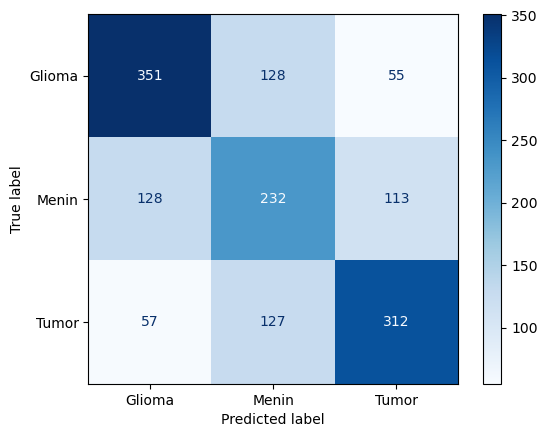

In [ ]:
logreg_cm_display = ConfusionMatrixDisplay(confusion_matrix = logreg_cm, display_labels = ["Glioma", "Menin", "Tumor"])
logreg_cm_display.plot(cmap = plt.cm.Blues)

<h3> Next Level - KNN

In [83]:
knn_accuracy = {}
for i in range(1, 500):
    model = KNeighborsClassifier(n_neighbors = i)
    model.fit(X_train, y_train)
    knn_accuracy[i] = model.score(X_test, y_test)

In [84]:
knn_accuracy

{1: 0.6872920825016633,
 2: 0.6580172987358616,
 3: 0.6912840984697272,
 4: 0.6646706586826348,
 5: 0.6813040585495675,
 6: 0.6706586826347305,
 7: 0.6806387225548902,
 8: 0.6706586826347305,
 9: 0.6739853626081171,
 10: 0.6706586826347305,
 11: 0.6766467065868264,
 12: 0.667332002661344,
 13: 0.6706586826347305,
 14: 0.6640053226879574,
 15: 0.6613439787092482,
 16: 0.6586826347305389,
 17: 0.6600133067198936,
 18: 0.6533599467731205,
 19: 0.6573519627411843,
 20: 0.6553559547571524,
 21: 0.6520292747837658,
 22: 0.6520292747837658,
 23: 0.6467065868263473,
 24: 0.6440452428476381,
 25: 0.6447105788423154,
 26: 0.6393878908848969,
 27: 0.6380572188955422,
 28: 0.6393878908848969,
 29: 0.635395874916833,
 30: 0.6373918829008649,
 31: 0.6387225548902196,
 32: 0.6373918829008649,
 33: 0.6387225548902196,
 34: 0.6393878908848969,
 35: 0.6407185628742516,
 36: 0.6407185628742516,
 37: 0.6420492348636061,
 38: 0.6413838988689288,
 39: 0.635395874916833,
 40: 0.6360612109115104,
 41: 0.63339

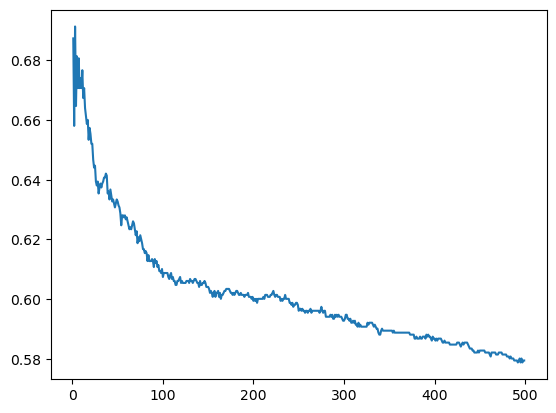

In [87]:
fig, ax = plt.subplots()
ax.plot(knn_accuracy.keys(), knn_accuracy.values())

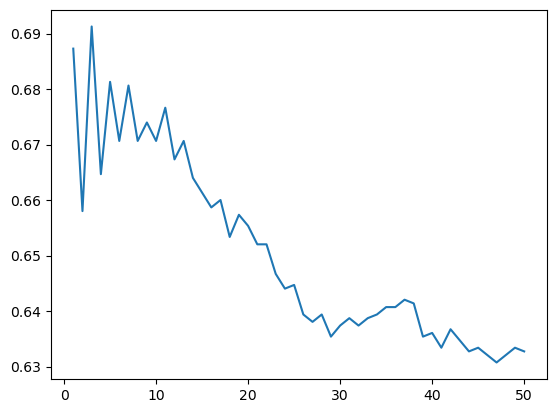

In [89]:
fig, ax = plt.subplots()
ax.plot(list(knn_accuracy.keys())[:50], list(knn_accuracy.values())[:50])

In [90]:
knn_model = KNeighborsClassifier(n_neighbors = 3)
knn_model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [131]:
knn_accuracy_score = knn_model.score(X_test, y_test)

In [107]:
y_pred_knn = knn_model.predict(X_test)

In [112]:
knn_f1 = f1_score(y_test, y_pred_knn, average = "weighted")
knn_f1

0.6609796741160536

In [165]:
knn_cm = confusion_matrix(y_test, y_pred_knn)

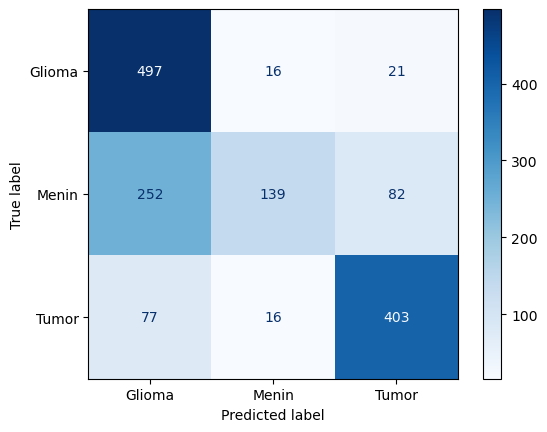

In [166]:
knn_cm_display = ConfusionMatrixDisplay(confusion_matrix = knn_cm, display_labels = ["Glioma", "Menin", "Tumor"])
knn_cm_display.plot(cmap = plt.cm.Blues)

<h3> Random Forest

In [ ]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [94]:
rf_model.score(X_test, y_test)

0.6959414504324684

In [97]:
rf_model2 = RandomForestClassifier(n_estimators = 500)
rf_model2.fit(X_train, y_train)

RandomForestClassifier(n_estimators=500)

In [98]:
rf_model2.score(X_test, y_test)

0.7232202262142382

In [101]:
rf_scores = {}
for i in range(100, 1100, 100):
    rf_model = RandomForestClassifier(n_estimators = i)
    rf_model.fit(X_train, y_train)
    rf_scores[i] = rf_model.score(X_test, y_test)


In [103]:
rf_scores

{100: 0.6959414504324684,
 200: 0.7085828343313373,
 300: 0.7092481703260146,
 400: 0.7172322022621423,
 500: 0.7258815701929474,
 600: 0.718562874251497,
 700: 0.7305389221556886,
 800: 0.7325349301397206,
 900: 0.7351962741184298,
 1000: 0.7198935462408517}

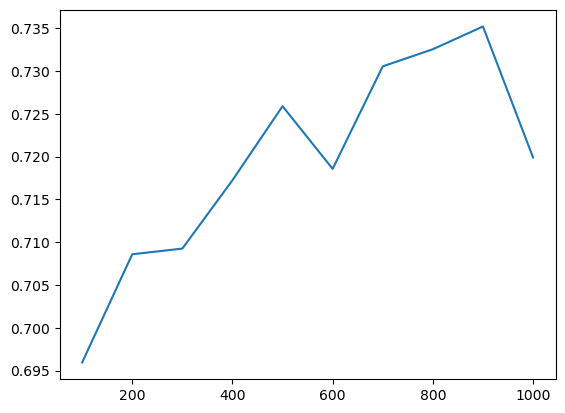

In [152]:
fig, ax = plt.subplots()
ax.plot(rf_scores.keys(), rf_scores.values())

In [153]:
rf_model3 = RandomForestClassifier(random_state=42, n_estimators = 900)
rf_model3.fit(X_train, y_train)

RandomForestClassifier(n_estimators=900, random_state=42)

In [154]:
rf_accuracy = rf_model3.score(X_test, y_test)
rf_accuracy

0.7272122421823021

In [155]:
rf_pred = rf_model3.predict(X_test)

In [156]:
rf_model_f1 = f1_score(rf_pred, y_test, average = "weighted")
rf_model_f1

0.729354687339949

In [ ]:
rf_cm = confusion_matrix(y_test, rf_pred)

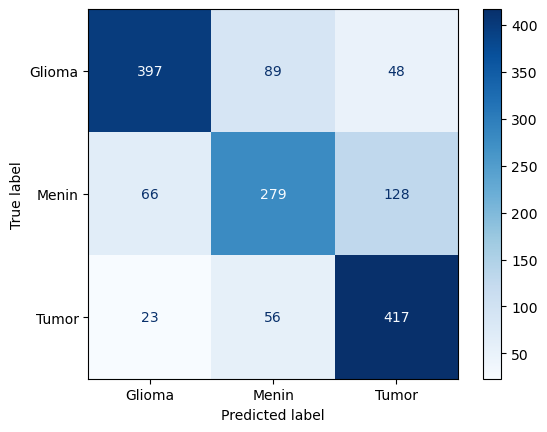

In [168]:
rf_cm_display = ConfusionMatrixDisplay(confusion_matrix = rf_cm, display_labels = ["Glioma", "Menin", "Tumor"])
rf_cm_display.plot(cmap = plt.cm.Blues)

<h3> Results

In [157]:
accuracy_f1 = pd.DataFrame([[logreg_accuracy, logreg_f1], [knn_accuracy_score, knn_f1], [rf_accuracy, rf_model_f1]], columns = ["Accuracy", "F1 Score"], index = ["Logistic Regression", "KNN", "Random Forest"])
accuracy_f1 = accuracy_f1.reset_index().melt(id_vars="index", var_name="Metric", value_name="Value")
accuracy_f1.rename(columns={"index" : "Model"}, inplace = True)
accuracy_f1

,Model,Metric,Value
0,Logistic Regression,Accuracy,0.595476
1,KNN,Accuracy,0.691284
2,Random Forest,Accuracy,0.727212
3,Logistic Regression,F1 Score,0.596191
4,KNN,F1 Score,0.660980
5,Random Forest,F1 Score,0.729355


In [171]:
fig = px.histogram(accuracy_f1.reset_index(), x = "Model", y = "Value", color = "Metric", barmode = "group", title = "Classification Model Performance", color_discrete_sequence = ["darkcyan", "lightblue"])
fig.update_layout(yaxis_title = "Value")
fig.show()

/Users/sami/opt/anaconda3/lib/python3.9/site-packages/plotly/express/_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

